# Clustering with K-Means and GMM

# 24BAD099 - Rithish A

In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

In [27]:
# Load dataset
data_path = r'd:\\class materials AI&DS\\sem 4\\ML\\Lab\\EXP-7\\Mall_Customers.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
display(df.head())
display(df.info())

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

In [28]:
# Preprocessing and feature selection
feature_cols = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[feature_cols].copy()

# Handle missing values 
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median(numeric_only=True))

# Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Using features:', feature_cols)

Using features: ['Annual Income (k$)', 'Spending Score (1-100)']


## Scenario 1: K-Means Clustering

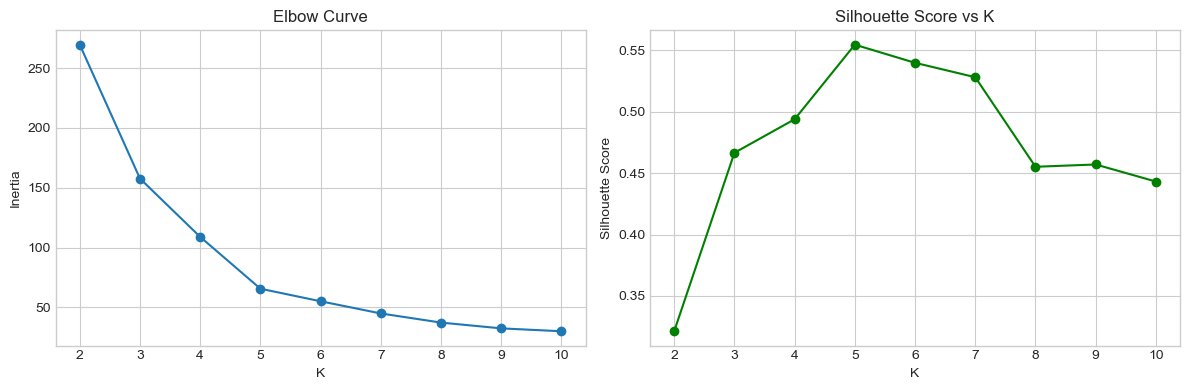

In [29]:
# 4. Elbow Method and Silhouette
k_values = range(2, 11)
inertias = []
sil_scores = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Curve')
plt.xlabel('K')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(list(k_values), sil_scores, marker='o', color='green')
plt.title('Silhouette Score vs K')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

kmeans_k = 5

In [30]:
# Apply K-Means and assign labels
kmeans = KMeans(n_clusters=kmeans_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

kmeans_inertia = kmeans.inertia_
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print('K-Means K =', kmeans_k)
print('Inertia =', round(kmeans_inertia, 4))
print('Silhouette =', round(kmeans_silhouette, 4))

K-Means K = 5
Inertia = 65.5684
Silhouette = 0.5547


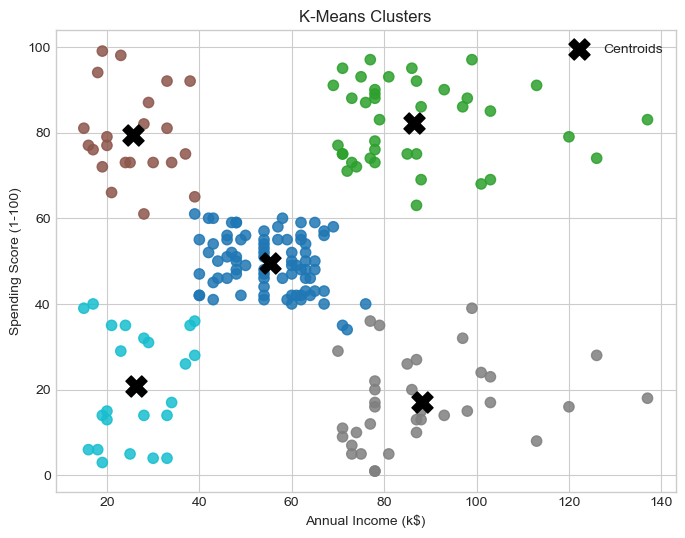

In [31]:
# Visualize K-Means clusters
plot_x = 'Annual Income (k$)'
plot_y = 'Spending Score (1-100)'

x_idx = feature_cols.index(plot_x)
y_idx = feature_cols.index(plot_y)
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(X[plot_x], X[plot_y], c=kmeans_labels, cmap='tab10', s=55, alpha=0.85)
plt.scatter(centers[:, x_idx], centers[:, y_idx], c='black', marker='X', s=230, label='Centroids')
plt.title('K-Means Clusters')
plt.xlabel(plot_x)
plt.ylabel(plot_y)
plt.legend()
plt.show()

In [32]:
# Cluster characteristics
print('Cluster sizes:')
display(df['KMeans_Cluster'].value_counts().sort_index().to_frame('Count'))

print('Cluster means:')
display(df.groupby('KMeans_Cluster')[feature_cols].mean().round(2))

Cluster sizes:


,Count
KMeans_Cluster,
0,81
1,39
2,22
3,35
4,23


Cluster means:


,Annual Income (k$),Spending Score (1-100)
KMeans_Cluster,,
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


## Scenario 2: Clustering Using Gaussian Mixture Model (GMM)

Best components by BIC: 5


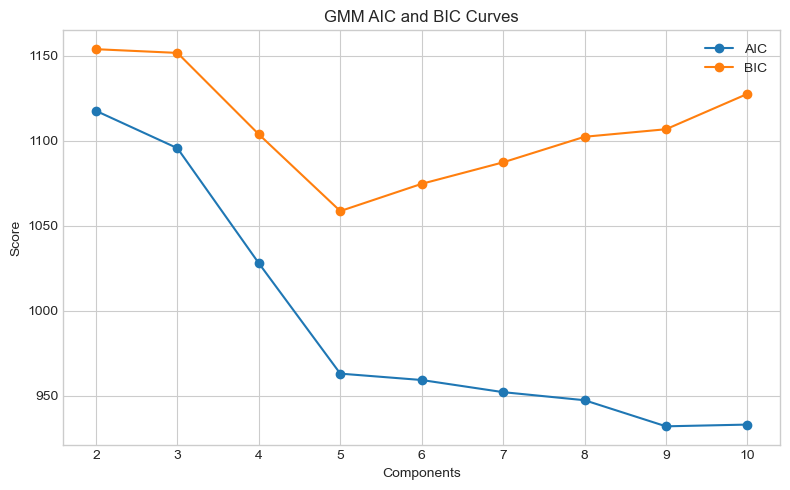

In [50]:
# GMM model selection with AIC and BIC curves
components = range(2, 11)
gmm_aic, gmm_bic, gmm_loglike, gmm_sil = [], [], [], []

for c in components:
    model = GaussianMixture(n_components=c, random_state=42)
    model.fit(X_scaled)
    labels = model.predict(X_scaled)
    gmm_aic.append(model.aic(X_scaled))
    gmm_bic.append(model.bic(X_scaled))
    gmm_loglike.append(model.score(X_scaled))
    gmm_sil.append(silhouette_score(X_scaled, labels))

best_c_bic = list(components)[int(np.argmin(gmm_bic))]
print('Best components by BIC:', best_c_bic)

plt.figure(figsize=(8, 5))
plt.plot(list(components), gmm_aic, marker='o', label='AIC')
plt.plot(list(components), gmm_bic, marker='o', label='BIC')
plt.title('GMM AIC and BIC Curves')
plt.xlabel('Components')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# Final GMM model and cluster probabilities
gmm = GaussianMixture(n_components=best_c_bic, random_state=42)
gmm.fit(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)
gmm_labels = gmm.predict(X_scaled)

df['GMM_Cluster'] = gmm_labels
df['GMM_Max_Prob'] = gmm_probs.max(axis=1)

print('GMM components =', best_c_bic)
print('Avg Log-Likelihood =', round(gmm.score(X_scaled), 4))
print('AIC =', round(gmm.aic(X_scaled), 4))
print('BIC =', round(gmm.bic(X_scaled), 4))
print('Silhouette =', round(silhouette_score(X_scaled, gmm_labels), 4))

GMM components = 5
Avg Log-Likelihood = -2.2625
AIC = 963.001
BIC = 1058.6523
Silhouette = 0.5537


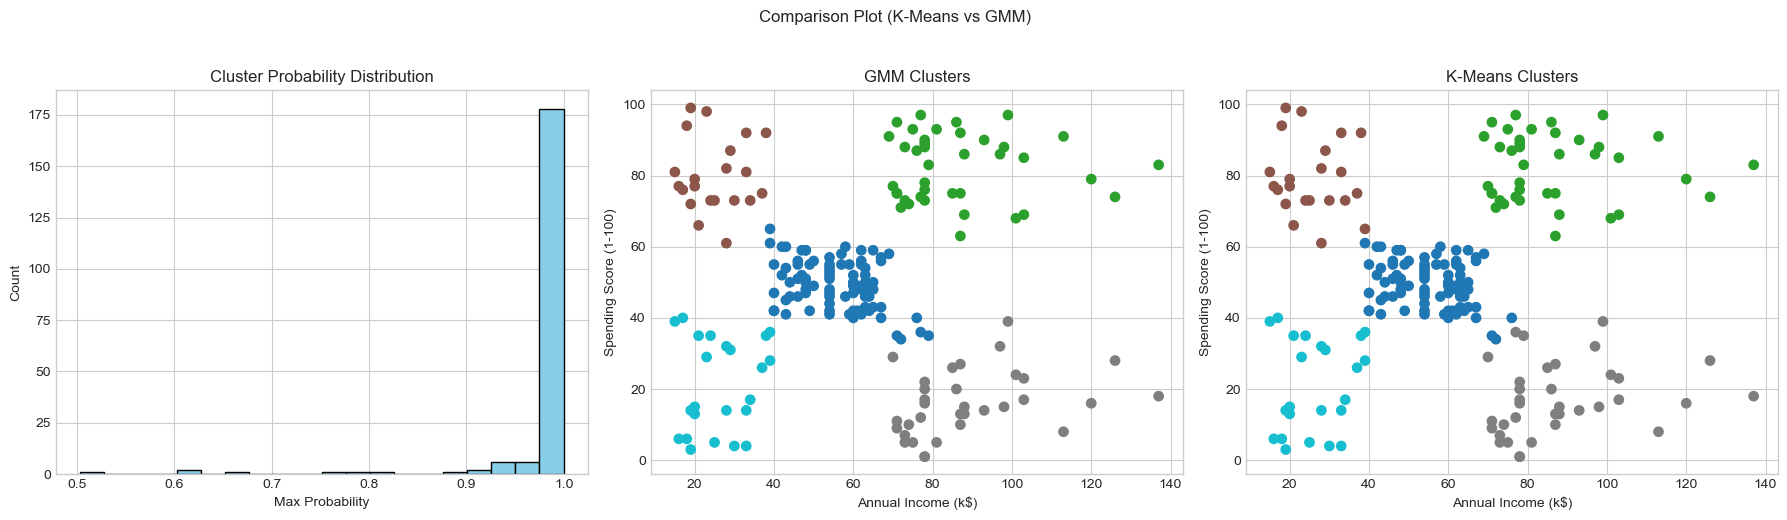

In [41]:
# Comparison plot (K-Means vs GMM) + Cluster probability distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Cluster probability distribution
axes[0].hist(df['GMM_Max_Prob'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Cluster Probability Distribution')
axes[0].set_xlabel('Max Probability')
axes[0].set_ylabel('Count')

# 2) GMM clusters
axes[1].scatter(X[plot_x], X[plot_y], c=gmm_labels, cmap='tab10', s=45)
axes[1].set_title('GMM Clusters')
axes[1].set_xlabel(plot_x)
axes[1].set_ylabel(plot_y)

# 3) K-Means clusters
axes[2].scatter(X[plot_x], X[plot_y], c=kmeans_labels, cmap='tab10', s=45)
axes[2].set_title('K-Means Clusters')
axes[2].set_xlabel(plot_x)
axes[2].set_ylabel(plot_y)

fig.suptitle('Comparison Plot (K-Means vs GMM)', y=1.03)
plt.tight_layout()
plt.show()

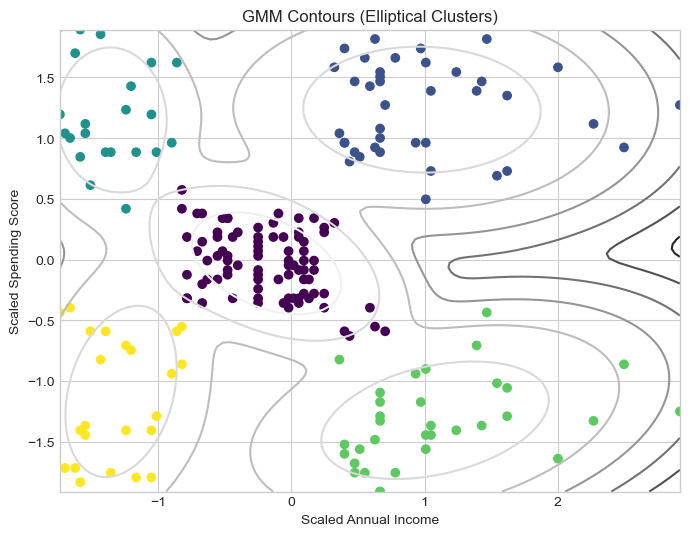

In [48]:
# Create grid for contour
x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)

XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

# Use the existing GMM labels for the scatter colors
labels = gmm_labels

plt.figure(figsize=(8, 6))
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.title('GMM Contours (Elliptical Clusters)')
plt.xlabel('Scaled Annual Income')
plt.ylabel('Scaled Spending Score')
plt.show()

In [37]:
# Final comparison table
comparison = pd.DataFrame({
    'Model': ['K-Means', 'GMM'],
    'Clusters/Components': [kmeans_k, best_c_bic],
    'Inertia': [kmeans_inertia, np.nan],
    'Silhouette': [silhouette_score(X_scaled, kmeans_labels), silhouette_score(X_scaled, gmm_labels)],
    'Avg Log-Likelihood': [np.nan, gmm.score(X_scaled)],
    'AIC': [np.nan, gmm.aic(X_scaled)],
    'BIC': [np.nan, gmm.bic(X_scaled)]
})

display(comparison)

,Model,Clusters/Components,Inertia,Silhouette,Avg Log-Likelihood,AIC,BIC
0,K-Means,5,65.568408,0.554657,NaN,NaN,NaN
1,GMM,5,NaN,0.553689,-2.262503,963.001049,1058.652252
